# Notebook 01b — Hand Dataset Augmentation
**FracAtlas YOLOv8s Fracture Detection Pipeline**

This notebook applies **medical-safe augmentations** to the hand X-ray subset to increase dataset size and improve model generalization.

## Augmentation Strategy (Anatomically Safe)

✅ **SAFE - Will Apply:**
- **Horizontal Flip** (p=0.5) — Safe for hand X-rays (left ↔ right symmetry)
- **Small Rotation** (±10°) — Simulates patient positioning variations
- **Brightness/Contrast** — Simulates different X-ray machine qualities
- **Mild Translation** (5%) — Hand positioning differences
- **Mild Scale** (15%) — Different hand sizes/distances

❌ **UNSAFE - Disabled:**
- **Vertical Flip** — Would make anatomy incorrect (bones upside down)
- **Shear** — Distorts bone structure
- **Perspective** — X-rays are projections, not perspective views
- **Hue/Saturation** — X-rays are grayscale

> **Run this AFTER Notebook 01 if you want to augment the hand subset.**

## 0. Install & Import Dependencies

In [1]:
# Install required packages (run once if not installed)
# !pip install albumentations opencv-python-headless pandas scikit-learn tqdm Pillow PyYAML

import os
import cv2
import yaml
import random
import shutil
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Configure Paths

In [2]:
# ─── EDIT THESE PATHS TO MATCH YOUR SETUP ───────────────────────────────────
# Note: Using parent directory since notebooks are in a subfolder
BASE_DIR       = Path.cwd().parent  # Go up one level from notebooks/
IMAGES_DIR     = BASE_DIR / "images"
ANNOT_DIR      = BASE_DIR / "Annotations" / "YOLO"
SPLITS_DIR     = BASE_DIR / "splits"
DATASET_CSV    = BASE_DIR / "dataset.csv"

# Output directories for augmented dataset
OUTPUT_DIR     = BASE_DIR / "yolo_dataset_hand_augmented"
YAML_PATH      = BASE_DIR / "fracatlas_hand_augmented.yaml"
# ─────────────────────────────────────────────────────────────────────────────

# Create output directory structure
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

YAML_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Base directory   : {BASE_DIR.resolve()}")
print(f"Images directory : {IMAGES_DIR.resolve()}")
print(f"Annotations dir  : {ANNOT_DIR.resolve()}")
print(f"Output dataset   : {OUTPUT_DIR.resolve()}")

Base directory   : D:\Project Medical Object Detection\FracAtlas
Images directory : D:\Project Medical Object Detection\FracAtlas\images
Annotations dir  : D:\Project Medical Object Detection\FracAtlas\Annotations\YOLO
Output dataset   : D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_augmented


## 2. Load Hand Dataset Information

In [3]:
# Load dataset metadata to identify hand images
df = pd.read_csv(DATASET_CSV)

# Filter for hand images only
hand_df = df[df['hand'] == 1].copy()
print(f"Total hand images in dataset: {len(hand_df)}")

# Check fracture distribution
n_frac = (hand_df['fractured'] == 1).sum()
n_non_frac = (hand_df['fractured'] == 0).sum()
print(f"  Fractured:     {n_frac} ({100*n_frac/len(hand_df):.1f}%)")
print(f"  Non-fractured: {n_non_frac} ({100*n_non_frac/len(hand_df):.1f}%)")
print(f"  Ratio (Non-frac / Frac): {n_non_frac / n_frac:.2f}:1")

# Create image_id to label mapping
img_to_label = {}
for _, row in hand_df.iterrows():
    img_id = row['image_id']
    is_fractured = row['fractured'] == 1
    img_to_label[img_id] = 'Fractured' if is_fractured else 'Non-fractured'

Total hand images in dataset: 1538
  Fractured:     438 (28.5%)
  Non-fractured: 1100 (71.5%)
  Ratio (Non-frac / Frac): 2.51:1


## 3. Define Medical-Safe Augmentation Pipeline

In [4]:
# ─── MEDICAL-SAFE AUGMENTATION PIPELINE ──────────────────────────────────────
# Designed specifically for hand X-ray fracture detection

augmentation_transform = A.Compose([
    # Geometric transformations (affect bounding boxes)
    A.HorizontalFlip(p=0.5),                    # Safe for symmetric anatomy
    A.Affine(
        rotate=(-10, 10),                       # ±10° rotation
        translate_percent=(-0.05, 0.05),        # ±5% translation
        scale=(0.85, 1.15),                     # ±15% scale
        shear=0,                                # Disabled - distorts anatomy
        p=0.7                                   # Apply 70% of the time
    ),
    
    # Photometric transformations (don't affect bounding boxes)
    A.RandomBrightnessContrast(
        brightness_limit=(-0.3, 0.3),           # Simulate X-ray exposure differences
        contrast_limit=(-0.2, 0.2),
        p=0.6
    ),
    
    # Slight noise to simulate X-ray grain
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    
    # Ensure output is in correct format
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=0.0  # Disabled by default - YOLO handles normalization
    ),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_area=100,  # Minimum bbox area in pixels
    min_visibility=0.3  # Minimum visibility fraction
))

print("Augmentation pipeline configured:")
print("  ✓ Horizontal Flip (p=0.5)")
print("  ✓ Rotation (±10°)")
print("  ✓ Translation (±5%)")
print("  ✓ Scale (±15%)")
print("  ✓ Brightness/Contrast (p=0.6)")
print("  ✓ Gaussian Noise (p=0.3)")
print("  ✗ Vertical Flip (DISABLED - anatomically unsafe)")
print("  ✗ Shear (DISABLED - distorts bone structure)")
print("  ✗ Hue/Saturation (DISABLED - X-rays are grayscale)")

Augmentation pipeline configured:
  ✓ Horizontal Flip (p=0.5)
  ✓ Rotation (±10°)
  ✓ Translation (±5%)
  ✓ Scale (±15%)
  ✓ Brightness/Contrast (p=0.6)
  ✓ Gaussian Noise (p=0.3)
  ✗ Vertical Flip (DISABLED - anatomically unsafe)
  ✗ Shear (DISABLED - distorts bone structure)
  ✗ Hue/Saturation (DISABLED - X-rays are grayscale)


## 4. Apply Augmentations

In [5]:
def load_yolo_bbox(label_path: Path, img_w: int, img_h: int):
    """Load YOLO format bounding boxes from label file."""
    bboxes = []
    class_labels = []
    
    if not label_path.exists():
        return bboxes, class_labels
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id, cx, cy, w, h = map(float, parts)
                bboxes.append([cx, cy, w, h])
                class_labels.append(int(cls_id))
    
    return bboxes, class_labels


def save_yolo_bbox(label_path: Path, bboxes: list, class_labels: list):
    """Save bounding boxes in YOLO format."""
    with open(label_path, 'w') as f:
        for bbox, cls_id in zip(bboxes, class_labels):
            f.write(f"{int(cls_id)} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")


def augment_image(img_path: Path, label_path: Path, output_img_path: Path, 
                  output_label_path: Path, n_augments: int = 1):
    """Apply augmentation to an image and save augmented versions."""
    
    # Load image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"  ⚠️  Failed to load image: {img_path}")
        return False
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Load bounding boxes
    bboxes, class_labels = load_yolo_bbox(label_path, img_w, img_h)
    
    # For non-fractured images (no bboxes), just create augmented copies
    if len(bboxes) == 0:
        # Save original as base
        cv2.imwrite(str(output_img_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        output_label_path.write_text("")  # Empty label file
        
        # Create augmented versions
        for i in range(n_augments):
            aug_img_path = output_img_path.parent / f"{output_img_path.stem}_aug{i}{output_img_path.suffix}"
            aug_label_path = output_label_path.parent / f"{output_label_path.stem}_aug{i}{output_label_path.suffix}"
            
            transformed = augmentation_transform(image=img, bboxes=[], class_labels=[])
            aug_img = transformed['image']
            
            cv2.imwrite(str(aug_img_path), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            aug_label_path.write_text("")  # Empty label file
        
        return True
    
    # For fractured images, apply augmentation with bbox transformation
    # Save original
    cv2.imwrite(str(output_img_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    save_yolo_bbox(output_label_path, bboxes, class_labels)
    
    # Create augmented versions
    for i in range(n_augments):
        aug_img_path = output_img_path.parent / f"{output_img_path.stem}_aug{i}{output_img_path.suffix}"
        aug_label_path = output_label_path.parent / f"{output_label_path.stem}_aug{i}{output_label_path.suffix}"
        
        try:
            transformed = augmentation_transform(image=img, bboxes=bboxes, class_labels=class_labels)
            aug_img = transformed['image']
            aug_bboxes = transformed['bboxes']
            aug_class_labels = transformed['class_labels']
            
            cv2.imwrite(str(aug_img_path), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            save_yolo_bbox(aug_label_path, aug_bboxes, aug_class_labels)
        except Exception as e:
            print(f"  ⚠️  Augmentation failed for {img_path.name}: {e}")
            # Save original as fallback
            cv2.imwrite(str(aug_img_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            save_yolo_bbox(aug_label_path, bboxes, class_labels)
    
    return True

In [6]:
# Get all hand image paths
hand_image_ids = hand_df['image_id'].tolist()

# Map image_id to actual file path
frac_dir = IMAGES_DIR / "Fractured"
non_frac_dir = IMAGES_DIR / "Non_fractured"

# Build a lookup table of all available images first
print(f"Scanning image directories...")
print(f"  Fractured dir: {frac_dir}")
print(f"  Non-fractured dir: {non_frac_dir}")

available_images = {}
for ext in ['.jpg', '.jpeg', '.png']:
    for img_path in frac_dir.glob(f"*{ext}"):
        available_images[img_path.name] = (img_path, True)  # True = fractured
    for img_path in non_frac_dir.glob(f"*{ext}"):
        available_images[img_path.name] = (img_path, False)  # False = non-fractured

print(f"Found {len(available_images)} total images in directories")

def find_image_path(img_id: str):
    """Find the actual image path for an image_id."""
    # Ensure img_id has extension
    if not any(img_id.endswith(ext) for ext in ['.jpg', '.jpeg', '.png']):
        img_id = img_id + '.jpg'  # Default extension
    
    if img_id in available_images:
        return available_images[img_id]
    return None, None

# Collect all hand images with their labels
hand_images = []
for img_id in hand_image_ids:
    img_path, is_fractured = find_image_path(img_id)
    if img_path:
        label_path = ANNOT_DIR / f"{img_path.stem}.txt"
        hand_images.append({
            'image_id': img_id,
            'img_path': img_path,
            'label_path': label_path,
            'is_fractured': is_fractured
        })
    else:
        print(f"  Warning: Image not found: {img_id}")

print(f"\nFound {len(hand_images)} hand images to augment")

# Tentukan berapa banyak versi augmentasi per gambar (misal: 1 asli + 1 augmentasi)
N_AUGMENTS_PER_IMAGE = 1 

for item in tqdm(hand_images):
    img_id = item['image_id']
    img_path = item['img_path']
    label_path = item['label_path']
    
    # Tentukan path output (sementara masukkan semua ke folder 'train')
    # Bagian split nanti yang akan memindahkannya
    output_img_path = OUTPUT_DIR / "train" / "images" / img_path.name
    output_label_path = OUTPUT_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    
    # Panggil fungsi augmentasi yang sudah Anda buat
    augment_image(
        img_path, 
        label_path, 
        output_img_path, 
        output_label_path, 
        n_augments=N_AUGMENTS_PER_IMAGE
    )

print(f"\n✅ Augmentasi selesai. Cek folder: {OUTPUT_DIR / 'train' / 'images'}")

Scanning image directories...
  Fractured dir: d:\Project Medical Object Detection\FracAtlas\images\Fractured
  Non-fractured dir: d:\Project Medical Object Detection\FracAtlas\images\Non_fractured
Found 4083 total images in directories

Found 1538 hand images to augment


100%|██████████| 1538/1538 [01:18<00:00, 19.67it/s]


✅ Augmentasi selesai. Cek folder: d:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_augmented\train\images


## 5. Create Train/Val/Test Splits

In [7]:
from sklearn.model_selection import train_test_split
import os

# 1. Ambil semua gambar yang baru saja dibuat di folder train
all_extensions = ["*.png", "*.jpg", "*.jpeg"]
augmented_images = []
for ext in all_extensions:
    augmented_images.extend(list((OUTPUT_DIR / "train" / "images").glob(ext)))

print(f"Total augmented images found: {len(augmented_images)}")

# Cek jika kosong untuk menghindari crash
if len(augmented_images) == 0:
    raise ValueError("Folder output masih kosong! Pastikan loop augmentasi di Bagian 4 sudah dijalankan.")

# 2. Definisikan status fraktur untuk stratifikasi
def get_image_fracture_status(img_path: Path) -> int:
    label_path = OUTPUT_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    if label_path.exists() and label_path.stat().st_size > 0:
        return 1  # Fractured
    return 0  # Non-fractured

fracture_labels = [get_image_fracture_status(img) for img in augmented_images]

# 3. Lakukan Split (70% Train, 15% Val, 15% Test)
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    augmented_images, fracture_labels, 
    test_size=0.30, stratify=fracture_labels, random_state=42
)

val_imgs, test_imgs, _, _ = train_test_split(
    temp_imgs, temp_labels,
    test_size=0.50, stratify=temp_labels, random_state=42
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_imgs)} images")
print(f"  Val:   {len(val_imgs)} images")
print(f"  Test:  {len(test_imgs)} images")

# 4. Fungsi untuk memindahkan file (Gunakan shutil.move)
def move_to_split(imgs: list, split_name: str):
    if split_name == "train": return # Data sudah di folder train, tidak perlu pindah
    
    for img_path in imgs:
        img_name = img_path.name
        label_name = f"{img_path.stem}.txt"
        
        # Pindahkan Image
        dst_img = OUTPUT_DIR / split_name / "images" / img_name
        shutil.move(str(img_path), str(dst_img))
        
        # Pindahkan Label
        src_label = OUTPUT_DIR / "train" / "labels" / label_name
        dst_label = OUTPUT_DIR / split_name / "labels" / label_name
        if src_label.exists():
            shutil.move(str(src_label), str(dst_label))

# Eksekusi pemindahan (Hanya untuk val dan test karena data asal ada di train)
move_to_split(val_imgs, "val")
move_to_split(test_imgs, "test")

print("\n✓ Splits created and organized successfully!")

Total augmented images found: 3076

Dataset splits:
  Train: 2153 images
  Val:   461 images
  Test:  462 images

✓ Splits created and organized successfully!


## 6. Verify Final Dataset Statistics

In [8]:
# Count images and labels per split
def count_images_and_labels(split: str):
    img_dir = OUTPUT_DIR / split / "images"
    label_dir = OUTPUT_DIR / split / "labels"
    
    images = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg"))
    n_images = len(images)
    
    n_frac = 0
    n_non_frac = 0
    
    for img in images:
        label_path = label_dir / f"{img.stem}.txt"
        if label_path.exists() and label_path.stat().st_size > 0:
            n_frac += 1
        else:
            n_non_frac += 1
    
    return n_images, n_frac, n_non_frac

print("\n📊 Augmented Hand Dataset Summary:")
print("=" * 60)
print(f"{'Split':<10} | {'Images':<8} | {'Fractured':<12} | {'Non-fractured':<15}")
print("=" * 60)

total_images = 0
total_frac = 0
total_non_frac = 0

for split in ["train", "val", "test"]:
    n_img, n_frac, n_non_frac = count_images_and_labels(split)
    total_images += n_img
    total_frac += n_frac
    total_non_frac += n_non_frac
    print(f"{split.capitalize():<10} | {n_img:<8} | {n_frac:<12} | {n_non_frac:<15}")

print("=" * 60)
print(f"{'TOTAL':<10} | {total_images:<8} | {total_frac:<12} | {total_non_frac:<15}")
print("\n✓ Dataset augmentation complete!")


📊 Augmented Hand Dataset Summary:
Split      | Images   | Fractured    | Non-fractured  
Train      | 2153     | 613          | 1540           
Val        | 461      | 131          | 330            
Test       | 462      | 132          | 330            
TOTAL      | 3076     | 876          | 2200           

✓ Dataset augmentation complete!


## 7. Generate YOLO Configuration YAML

In [9]:
# Create YAML configuration for YOLO
yaml_config = {
    'path': str(OUTPUT_DIR.resolve()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['fracture']
}

# Save YAML file
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=None, sort_keys=False)

print(f"✓ YAML config saved to: {YAML_PATH}")
print("\nYAML contents:")
print("-" * 40)
with open(YAML_PATH) as f:
    print(f.read())

✓ YAML config saved to: d:\Project Medical Object Detection\FracAtlas\fracatlas_hand_augmented.yaml

YAML contents:
----------------------------------------
path: D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_augmented
train: train/images
val: val/images
test: test/images
nc: 1
names: [fracture]



## 8. Visualize Augmented Samples

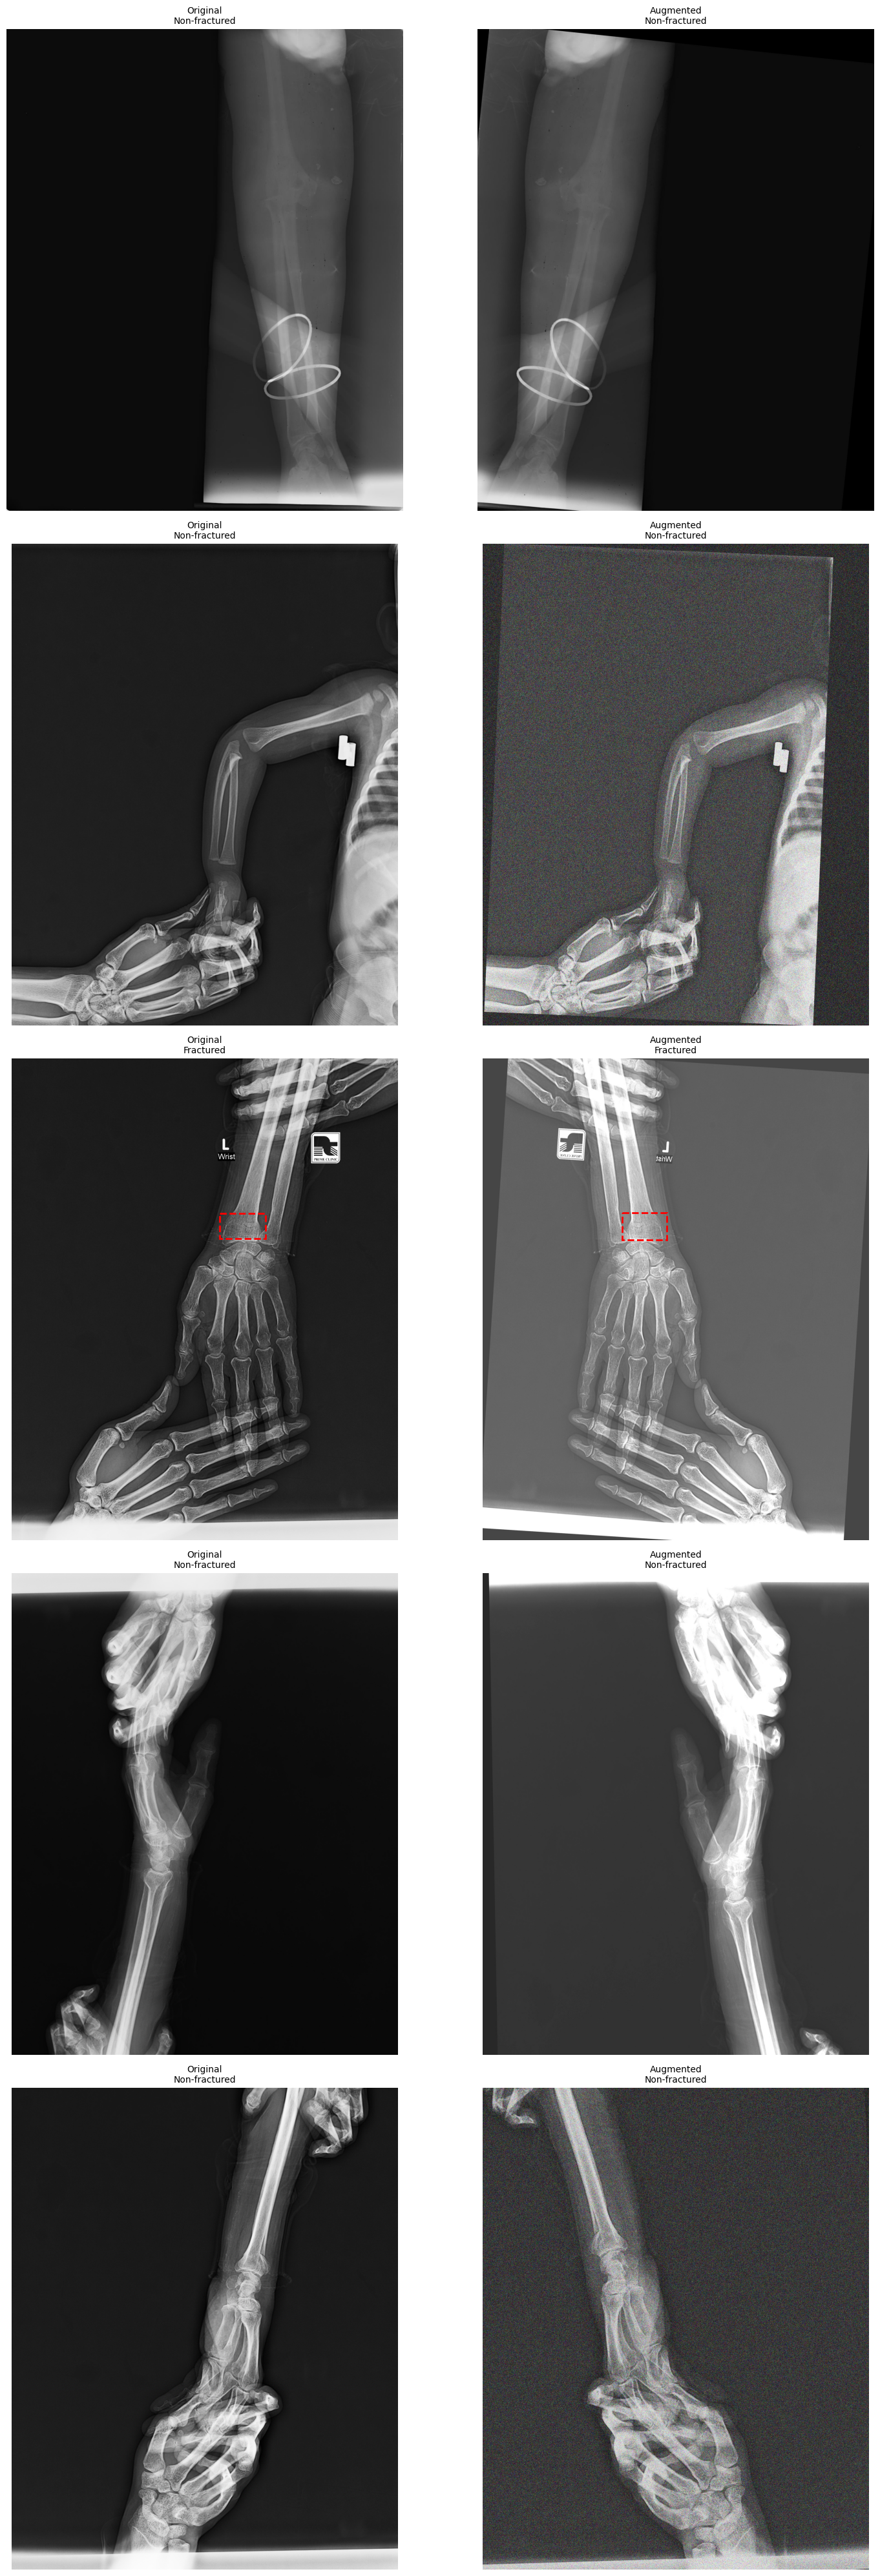


✓ Visualized 5 original vs augmented image pairs


In [10]:
def visualize_augmented_sample(img_path: Path, label_path: Path, ax):
    """Visualize an augmented image with its bounding boxes."""
    # Load image
    img = cv2.imread(str(img_path))
    if img is None:
        ax.set_title(f"Failed to load: {img_path.name}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Load bounding boxes
    bboxes = []
    if label_path.exists() and label_path.stat().st_size > 0:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, w, h = map(float, parts)
                    # Convert YOLO to pixel coordinates
                    x1 = int((cx - w/2) * img_w)
                    y1 = int((cy - h/2) * img_h)
                    x2 = int((cx + w/2) * img_w)
                    y2 = int((cy + h/2) * img_h)
                    bboxes.append([x1, y1, x2, y2])
    
    # Display image
    ax.imshow(img)
    
    # Draw bounding boxes
    for bbox in bboxes:
        rect = plt.Rectangle(
            (bbox[0], bbox[1]), 
            bbox[2] - bbox[0], 
            bbox[3] - bbox[1],
            fill=False, 
            color='red', 
            linewidth=2,
            linestyle='--'
        )
        ax.add_patch(rect)
    
    # Title
    is_aug = "_aug" in img_path.stem
    has_bbox = len(bboxes) > 0
    title = f"{'Augmented' if is_aug else 'Original'}\n"
    title += f"Fractured" if has_bbox else "Non-fractured"
    ax.set_title(title, fontsize=10)
    ax.axis('off')


# Sample some images for visualization
train_img_dir = OUTPUT_DIR / "train" / "images"
train_label_dir = OUTPUT_DIR / "train" / "labels"

# Get original and augmented versions of same image
all_extensions = ["*.png", "*.jpg", "*.jpeg"]
all_imgs = []
for ext in all_extensions:
    all_imgs.extend(list(train_img_dir.glob(ext)))

# Find images with augmentations
augmented_samples = []
for img in all_imgs:
    if "_aug" in img.stem:
        # Find corresponding original
        base_name = img.stem.split("_aug")[0]
        # Try all extensions for the original
        original_img = None
        for ext in all_extensions:
            orig_candidate = train_img_dir / f"{base_name}{ext.replace('*', '')}"
            if orig_candidate.exists():
                original_img = orig_candidate
                break
        
        if original_img and original_img.exists():
            augmented_samples.append((original_img, img))
            if len(augmented_samples) >= 5:
                break

# Create visualization
if len(augmented_samples) > 0:
    fig, axes = plt.subplots(len(augmented_samples), 2, figsize=(16, 8 * len(augmented_samples)))
    
    if len(augmented_samples) == 1:
        axes = np.array([axes])
    
    for i, (orig_img, aug_img) in enumerate(augmented_samples):
        orig_label = train_label_dir / f"{orig_img.stem}.txt"
        aug_label = train_label_dir / f"{aug_img.stem}.txt"
        
        visualize_augmented_sample(orig_img, orig_label, axes[i, 0])
        visualize_augmented_sample(aug_img, aug_label, axes[i, 1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Visualized {len(augmented_samples)} original vs augmented image pairs")
else:
    print("\n⚠️ No augmented image pairs found for visualization")
    print("This may happen if augmentation was not applied or failed")

## 9. Summary & Next Steps

In [11]:
print("\n" + "=" * 70)
print("AUGMENTATION COMPLETE - SUMMARY")
print("=" * 70)
print(f"\n📁 Output directory: {OUTPUT_DIR}")
print(f"📄 YAML config: {YAML_PATH}")
print(f"\n📊 Dataset Statistics:")
print(f"   Total images: {total_images}")
print(f"   - Fractured: {total_frac} ({100*total_frac/total_images:.1f}%)")
print(f"   - Non-fractured: {total_non_frac} ({100*total_non_frac/total_images:.1f}%)")
print(f"\n📈 Augmentation Applied:")
print(f"   ✓ Horizontal Flip (p=0.5)")
print(f"   ✓ Rotation (±10°)")
print(f"   ✓ Translation (±5%)")
print(f"   ✓ Scale (±15%)")
print(f"   ✓ Brightness/Contrast (p=0.6)")
print(f"   ✓ Gaussian Noise (p=0.3)")
print(f"\n🚫 Disabled (Anatomically Unsafe):")
print(f"   ✗ Vertical Flip")
print(f"   ✗ Shear")
print(f"   ✗ Hue/Saturation")
print(f"\n➡️  Next Step: Use '{YAML_PATH.name}' in training notebook (02_training_yolov8.ipynb)")
print("=" * 70)


AUGMENTATION COMPLETE - SUMMARY

📁 Output directory: d:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_augmented
📄 YAML config: d:\Project Medical Object Detection\FracAtlas\fracatlas_hand_augmented.yaml

📊 Dataset Statistics:
   Total images: 3076
   - Fractured: 876 (28.5%)
   - Non-fractured: 2200 (71.5%)

📈 Augmentation Applied:
   ✓ Horizontal Flip (p=0.5)
   ✓ Rotation (±10°)
   ✓ Translation (±5%)
   ✓ Scale (±15%)
   ✓ Brightness/Contrast (p=0.6)
   ✓ Gaussian Noise (p=0.3)

🚫 Disabled (Anatomically Unsafe):
   ✗ Vertical Flip
   ✗ Shear
   ✗ Hue/Saturation

➡️  Next Step: Use 'fracatlas_hand_augmented.yaml' in training notebook (02_training_yolov8.ipynb)
